# Air Pollution & Death Rate Analysis (Categorical Mortality Clusters)

**Goal:** Build a supervised learning pipeline that predicts **discrete mortality risk bands** (`mortality_cluster`: low → high) from air-pollution and related features, after deriving those bands from observed death rates.

**Data:** `final_datasets/log_transformed_dataset(without-null-values).csv` (log-transformed features, no missing values; **~1,647 rows** in the original run).

**High-level workflow**

| Stage | What you do |
|-------|----------------|
| 1 | Load data, inspect **DeathRate** distribution |
| 2 | **KMeans on all numeric features** (exploratory): clusters do *not* align cleanly with death rate → not used as target |
| 3 | **KMeans on DeathRate only** → 4 ordered clusters → **`mortality_cluster`** (0–3) becomes the classification target |
| 4 | Drop **DeathRate** from modeling features (avoid leakage), save categorical dataset |
| 5 | EDA: correlation heatmap, correlations with target |
| 6 | **Time-based split:** train 2010–2015, val 2016, test 2017–2018 |
| 7 | **Random Forest** + `GridSearchCV`; **KNN** + optional grid for `n_neighbors`; compare importances / permutation importance |

**Models used:** `RandomForestClassifier`, `KNeighborsClassifier`, `KMeans`, `StandardScaler` (clustering only).


## 1. Imports


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, ConfusionMatrixDisplay
from sklearn.inspection import permutation_importance

pd.options.display.max_columns = 20


## 2. Load dataset & death rate distribution


Shape: (1647, 11)
Columns: ['Country_ISO', 'Year', 'DeathRate', 'Population (GPWv4.11)', 'CO Population-Weighted (ppm)', 'VOCs Population-Weighted (ppm)', 'SO2 Population-Weighted (ppm)', 'NOx Population-Weighted (ppm)', 'O3 Population-Weighted (ppm)', 'PM Pop.-Weighted (kg m^-3)', 'HospitalBeds']


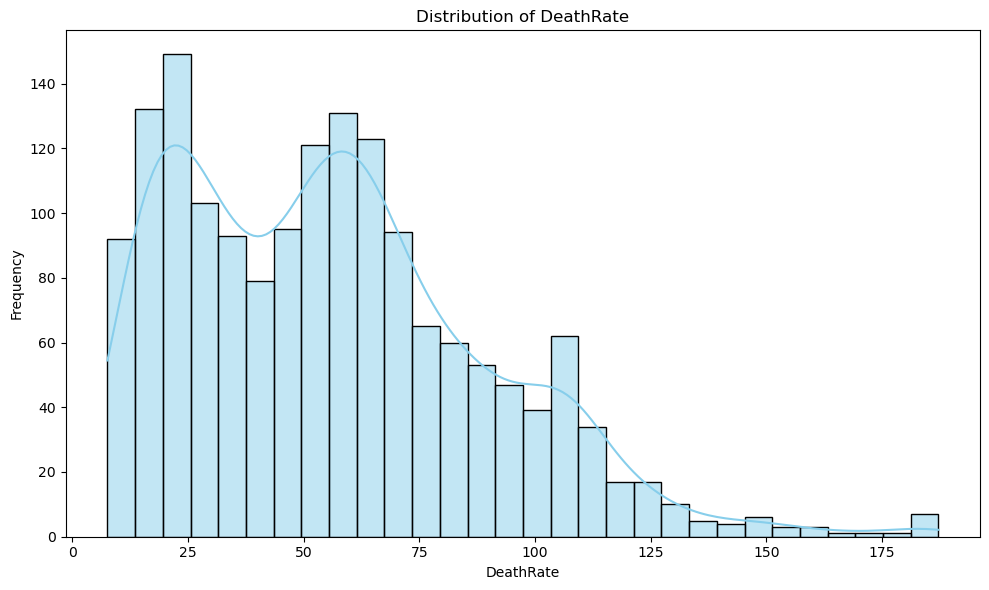

In [2]:
DATA_PATH = "final_datasets/log_transformed_dataset(without-null-values).csv"
merged_air_pollution_deaths_no_nan_df = pd.read_csv(DATA_PATH)

print("Shape:", merged_air_pollution_deaths_no_nan_df.shape)
print("Columns:", list(merged_air_pollution_deaths_no_nan_df.columns))

plt.figure(figsize=(10, 6))
sns.histplot(data=merged_air_pollution_deaths_no_nan_df, x="DeathRate", bins=30, kde=True, color="skyblue")
plt.title("Distribution of DeathRate")
plt.xlabel("DeathRate")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()


## 3. Unsupervised learning — KMeans on *all* numeric features (exploratory)

**Purpose:** Check whether natural groups in scaled pollution / demographic space match mortality levels.

**Note:** The notebook title mentions hierarchical clustering, but only **KMeans** is implemented here.

Steps:
- Select numeric columns; exclude identifiers (`Year`, `country_iso` if present).
- Impute any remaining NaNs with column means; **standardize** features.
- **Elbow method:** inertia vs *k* for *k* = 2,…,10.


Rows: 1647


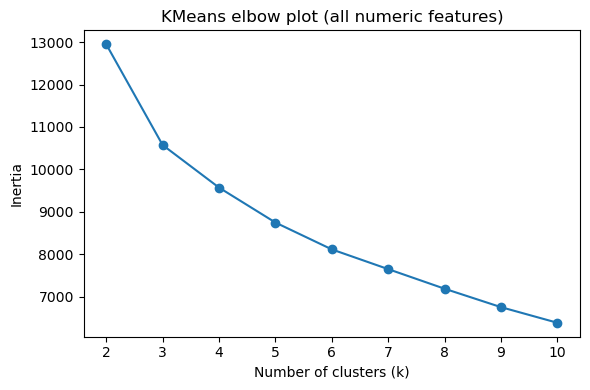

In [3]:
print("Rows:", merged_air_pollution_deaths_no_nan_df.shape[0])

numeric_cols = merged_air_pollution_deaths_no_nan_df.select_dtypes(include="number").columns.tolist()
exclude_cols = ["country_iso"]
exclude_cols = [c for c in exclude_cols if c in numeric_cols]
numeric_cols = [c for c in numeric_cols if c not in exclude_cols]

X_all = merged_air_pollution_deaths_no_nan_df[numeric_cols].copy()
X_all = X_all.fillna(X_all.mean())

scaler_all = StandardScaler()
X_scaled = scaler_all.fit_transform(X_all)

inertia = []
K_range = range(2, 11)
for k in K_range:
    km = KMeans(n_clusters=k, n_init=10, random_state=0)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(6, 4))
plt.plot(list(K_range), inertia, marker="o")
plt.title("KMeans elbow plot (all numeric features)")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.tight_layout()
plt.show()


### 3.1 KMeans with *k* = 4 (multi-feature clusters vs DeathRate)

Labels 0–3 are **arbitrary** here (not ordered by mortality). Group-wise **DeathRate** stats often **overlap heavily**, so these clusters are **not** used as the supervised target.


In [4]:
kmeans_multi = KMeans(n_clusters=4, n_init=10, random_state=1)
labels_multi = kmeans_multi.fit_predict(X_scaled)

stats_multi = (
    merged_air_pollution_deaths_no_nan_df.assign(_lbl=labels_multi)
    .groupby("_lbl")["DeathRate"]
    .agg(["min", "max", "mean", "std"])
)
stats_multi.index.name = "kmeans_label"
print(stats_multi)


                min     max       mean        std
kmeans_label                                     
0              7.57  187.20  49.211895  37.446875
1             21.70  167.70  70.327345  27.858482
2             15.28  125.70  67.176893  29.809255
3              8.61   89.46  35.201037  18.854731


**Interpretation:** Overlap in min/max/mean **DeathRate** across clusters means partitioning in *pollution-demographic* space does not yield clean, interpretable mortality strata. The analysis therefore switches to clustering **only** on **DeathRate** for the target definition.


## 4. Target definition — KMeans on **DeathRate** only → `mortality_cluster`

- **k = 4** → semantic bands: **low, moderate, elevated, high** (ordered by increasing death rate).
- Cluster IDs are **renumbered** 0–3 so that **0 = lowest** death-rate cluster and **3 = highest** (by sorting cluster centers).


In [5]:
death_rate_values = merged_air_pollution_deaths_no_nan_df[["DeathRate"]].values
kmeans_dr = KMeans(n_clusters=4, random_state=42)
raw_labels = kmeans_dr.fit_predict(death_rate_values)

# Order clusters by center so 0 = lowest mortality, 3 = highest
centers_sorted_idx = np.argsort(kmeans_dr.cluster_centers_.flatten())
label_remap = {int(old): int(new) for new, old in enumerate(centers_sorted_idx)}
merged_air_pollution_deaths_no_nan_df["mortality_cluster"] = [label_remap[int(x)] for x in raw_labels]

deathrate_category_map = {0: "low", 1: "moderate", 2: "elevated", 3: "high"}

stats_deathrate = (
    merged_air_pollution_deaths_no_nan_df.groupby("mortality_cluster")["DeathRate"]
    .agg(["count", "min", "max", "mean", "std"])
    .sort_index()
)
print(stats_deathrate)
print("\nCluster centers (DeathRate, same order as 0..3):", np.sort(kmeans_dr.cluster_centers_.flatten()))


                   count     min     max        mean        std
mortality_cluster                                              
0                    626    7.57   41.49   23.785559   8.928712
1                    636   41.61   77.29   59.241038   9.376882
2                    314   77.47  116.40   95.540510  10.976462
3                     71  117.50  187.20  138.554930  20.878326

Cluster centers (DeathRate, same order as 0..3): [ 23.78555911  59.24103774  95.54050955 138.55492958]


**How to read the table:** Each row is one risk band; **count** is the number of country-year records; **min/max/mean/std** describe **DeathRate** within that band. Boundaries are **data-driven** (Voronoi regions between KMeans centers), not fixed external thresholds.


## 5. Remove **DeathRate** from features (prevent label leakage)

The model must predict **mortality_cluster** from pollution and covariates only — **DeathRate** must not remain as an input feature.


In [6]:
merged_air_pollution_deaths_no_nan_df = merged_air_pollution_deaths_no_nan_df.drop(columns=["DeathRate"])
merged_air_pollution_deaths_no_nan_df.head()


,Country_ISO,Year,Population (GPWv4.11),CO Population-Weighted (ppm),VOCs Population-Weighted (ppm),SO2 Population-Weighted (ppm),NOx Population-Weighted (ppm),O3 Population-Weighted (ppm),PM Pop.-Weighted (kg m^-3),HospitalBeds,mortality_cluster
0,SLE,2018,15.648841,0.238096,0.061621,0.001599,0.004354,0.051219,4.936920e-08,0.770108,2
1,GIN,2018,16.415881,0.235465,0.072550,0.002074,0.004858,0.050023,4.568590e-08,0.262364,2
2,CAF,2018,15.467493,0.295000,0.261092,0.001055,0.004216,0.036538,3.312480e-08,0.693147,2
3,LSO,2018,14.589626,0.173338,0.030221,0.023580,0.017575,0.051924,1.172620e-08,0.770108,2
4,TCD,2018,16.550889,0.169458,0.101920,0.000606,0.003374,0.047606,4.279680e-08,0.375006,2


## 6. Class balance — counts per `mortality_cluster`


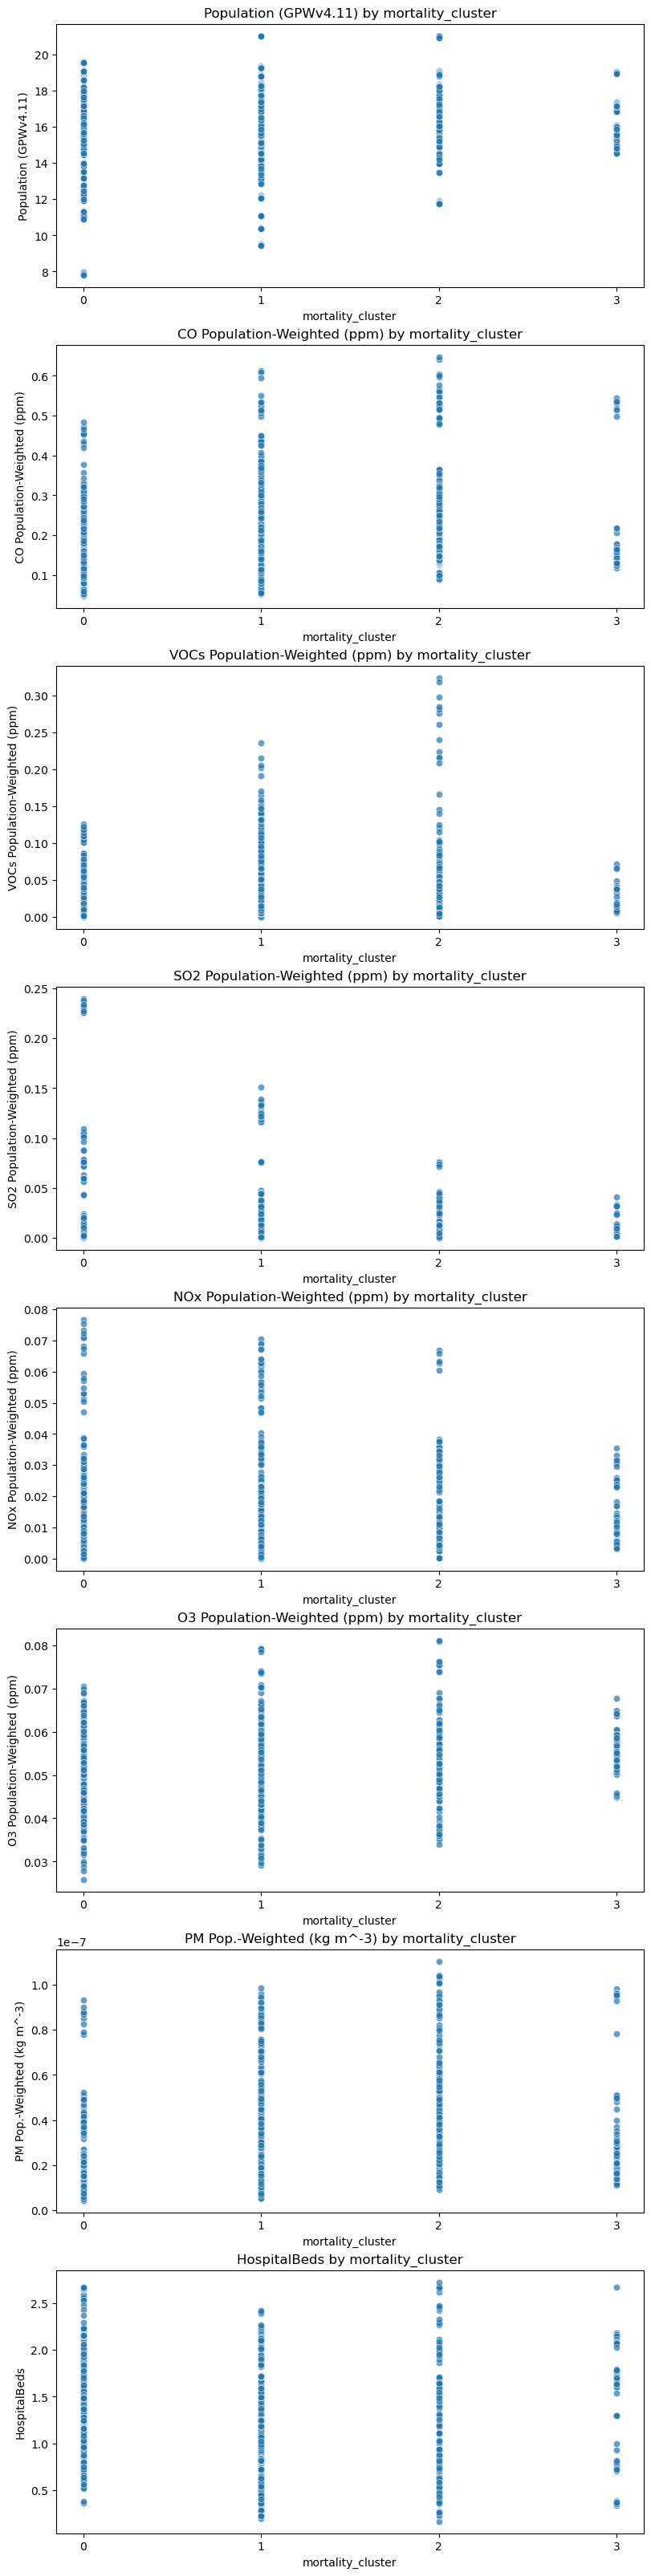

In [7]:
import matplotlib.pyplot as plt
# Set custom x-tick labels for mortality_cluster: 0, 1, 2, 3 (as per your mapping: low, moderate, elevated, high)
import seaborn as sns

# Exclude non-feature columns (e.g., country_iso, Year, mortality_cluster itself, Category, etc.)
exclude_cols = {'Country_ISO', 'Year', 'mortality_cluster', 'Category'}
feature_cols = [col for col in merged_air_pollution_deaths_no_nan_df.columns if col not in exclude_cols]

n_features = len(feature_cols)
fig, axes = plt.subplots(n_features, 1, figsize=(8, 4 * n_features), constrained_layout=True)

if n_features == 1:
    axes = [axes]

for ax, feature in zip(axes, feature_cols):
    sns.scatterplot(
        data=merged_air_pollution_deaths_no_nan_df,
        x="mortality_cluster",
        y=feature,
        ax=ax,
        alpha=0.7
    )
    ax.set_title(f"{feature} by mortality_cluster")
    ax.set_xlabel("mortality_cluster")
    ax.set_ylabel(feature)
    ax.set_xticks([0, 1, 2, 3])
    ax.set_xticklabels(['0', '1', '2', '3'])  # As requested: 0 1 2 3

plt.show()

In [8]:
category_counts = merged_air_pollution_deaths_no_nan_df["mortality_cluster"].value_counts().sort_index()
print("Counts per mortality_cluster:\n")
for cluster_label, count in category_counts.items():
    name = deathrate_category_map.get(cluster_label, f"cluster_{cluster_label}")
    print(f"  {cluster_label} ({name}): {count}")


Counts per mortality_cluster:

  0 (low): 626
  1 (moderate): 636
  2 (elevated): 314
  3 (high): 71


## 7. Correlation analysis

- **Heatmap:** pairwise linear associations among numeric columns (Year dropped from heatmap input for readability).
- **Bar chart:** Pearson correlation of each feature with **mortality_cluster** (ordinal 0–3 treated as numeric for a rough linear trend).


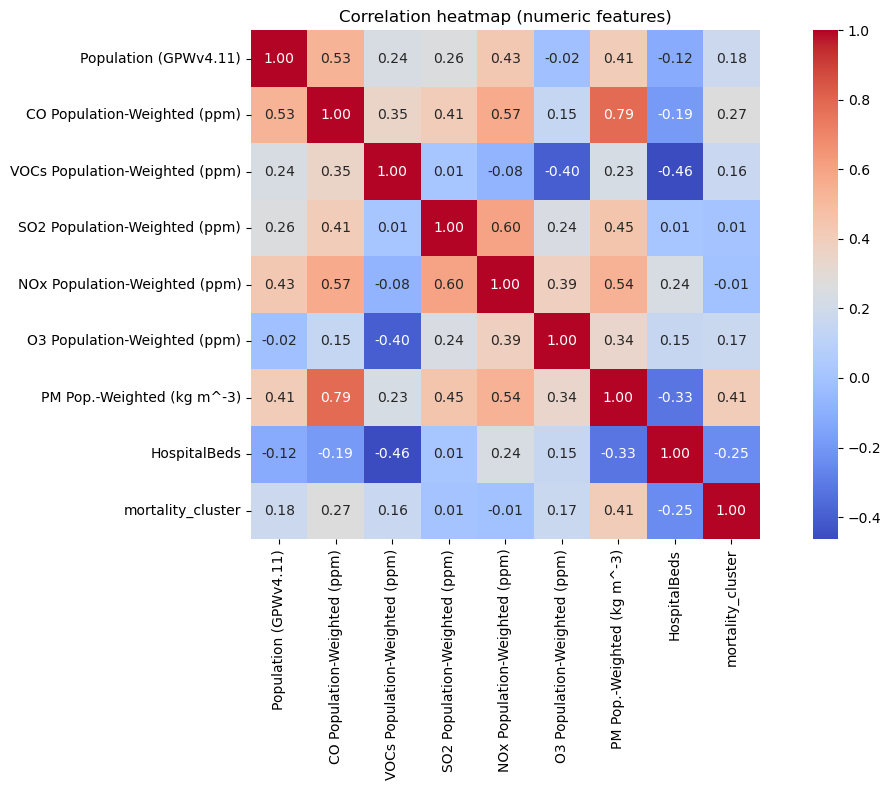

In [9]:
corr = merged_air_pollution_deaths_no_nan_df.drop(columns=["Year"], errors="ignore").corr(numeric_only=True)

plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Correlation heatmap (numeric features)")
plt.tight_layout()
plt.show()


Correlation 'Population (GPWv4.11)' vs mortality_cluster: 0.1763
Correlation 'CO Population-Weighted (ppm)' vs mortality_cluster: 0.2736
Correlation 'VOCs Population-Weighted (ppm)' vs mortality_cluster: 0.1600
Correlation 'SO2 Population-Weighted (ppm)' vs mortality_cluster: 0.0054
Correlation 'NOx Population-Weighted (ppm)' vs mortality_cluster: -0.0079
Correlation 'O3 Population-Weighted (ppm)' vs mortality_cluster: 0.1673
Correlation 'PM Pop.-Weighted (kg m^-3)' vs mortality_cluster: 0.4111
Correlation 'HospitalBeds' vs mortality_cluster: -0.2454


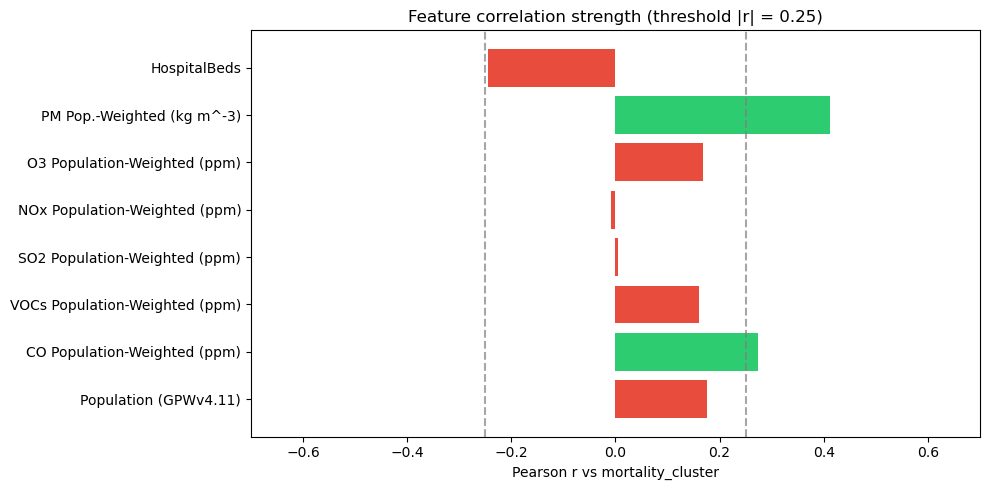

In [10]:
features = [
    col
    for col in merged_air_pollution_deaths_no_nan_df.columns
    if col not in ["Year", "Country_ISO", "mortality_cluster"]
]
correlations = []
for feature in features:
    c = merged_air_pollution_deaths_no_nan_df[feature].corr(
        merged_air_pollution_deaths_no_nan_df["mortality_cluster"]
    )
    correlations.append(c)
    print(f"Correlation '{feature}' vs mortality_cluster: {c:.4f}")

colors = ["#2ecc71" if abs(c) >= 0.25 else "#e74c3c" for c in correlations]
fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(features, correlations, color=colors)
ax.axvline(x=0.25, color="gray", linestyle="--", alpha=0.7)
ax.axvline(x=-0.25, color="gray", linestyle="--", alpha=0.7)
ax.set_xlabel("Pearson r vs mortality_cluster")
ax.set_title("Feature correlation strength (threshold |r| = 0.25)")
ax.set_xlim(-0.7, 0.7)
plt.tight_layout()
plt.show()


### Summary — typical correlation story (verify on your run)

| Feature   | Typical strength | Direction (higher feature → higher cluster code) |
|-----------|------------------|---------------------------------------------------|
| PM (pop.-weighted) | moderate–strong | ↑ |
| CO | moderate | ↑ |
| VOCs, Population, O3 | weak–moderate | ↑ |
| SO2, NOx | often negligible | varies |

Exact numbers depend on the current CSV; use the printed correlations and plot above.


## 8. Export dataset with categorical target


In [11]:
OUT_csv = "final_datasets/log_transformed_dataset(without-null-values)_categorical.csv"
merged_air_pollution_deaths_no_nan_df.to_csv(OUT_csv, index=False)
print("Saved:", OUT_csv)


Saved: final_datasets/log_transformed_dataset(without-null-values)_categorical.csv


## 10. Temporal train / validation / test split

**Rationale:** Same countries appear across years — a **random** split would leak future years into training. A **time-based** split better mimics *forecasting* later years.

| Split | Years | Role |
|-------|-------|------|
| Train | 2010–2015 | Fit models & grid search |
| Validation | 2016 | Tune / diagnose |
| Test | 2017–2018 | Final generalization estimate |


In [12]:
train_years = [2010, 2011, 2012, 2013, 2014, 2015]
val_years = [2016]
test_years = [2017, 2018]

train_df = merged_air_pollution_deaths_no_nan_df[merged_air_pollution_deaths_no_nan_df["Year"].isin(train_years)].reset_index(drop=True)
val_df = merged_air_pollution_deaths_no_nan_df[merged_air_pollution_deaths_no_nan_df["Year"].isin(val_years)].reset_index(drop=True)
test_df = merged_air_pollution_deaths_no_nan_df[merged_air_pollution_deaths_no_nan_df["Year"].isin(test_years)].reset_index(drop=True)

print("Train:\n", train_df["mortality_cluster"].value_counts().sort_index())
print("\nValidation:\n", val_df["mortality_cluster"].value_counts().sort_index())
print("\nTest:\n", test_df["mortality_cluster"].value_counts().sort_index())
print("\nShapes — train:", train_df.shape, " val:", val_df.shape, " test:", test_df.shape)


Train:
 mortality_cluster
0    405
1    418
2    221
3     54
Name: count, dtype: int64

Validation:
 mortality_cluster
0    72
1    72
2    33
3     6
Name: count, dtype: int64

Test:
 mortality_cluster
0    149
1    146
2     60
3     11
Name: count, dtype: int64

Shapes — train: (1098, 11)  val: (183, 11)  test: (366, 11)


## 11. Supervised learning — feature matrix and target

**Random Forest** is a strong default here: mixed feature types (after preprocessing), nonlinear effects, no scaling required, **feature importances**, robustness to noise.

**Features:** all columns except `Country_ISO` and `mortality_cluster`.


In [13]:
FEATURE_COLS = [c for c in train_df.columns if c not in ["Country_ISO", "mortality_cluster"]]
TARGET_COL = "mortality_cluster"

X_train = train_df[FEATURE_COLS]
y_train = train_df[TARGET_COL]
X_val = val_df[FEATURE_COLS]
y_val = val_df[TARGET_COL]
X_test = test_df[FEATURE_COLS]
y_test = test_df[TARGET_COL]


### 11.1 Random Forest — `GridSearchCV`

Search space (illustrative): `n_estimators`, `max_depth`, `min_samples_split`, `min_samples_leaf`, `class_weight`. **cv=3** for speed; increase for final reporting if needed.

The **final** fitted model in the next cell uses **fixed** hyperparameters aligned with a strong configuration (`n_estimators=300`, `max_depth=None`, `class_weight='balanced'`); re-run with `grid_search.best_estimator_` if you want the search result wired through end-to-end.


Fitting 3 folds for each of 216 candidates, totalling 648 fits
Best parameters: {'class_weight': 'balanced', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}
Best CV accuracy: 0.935


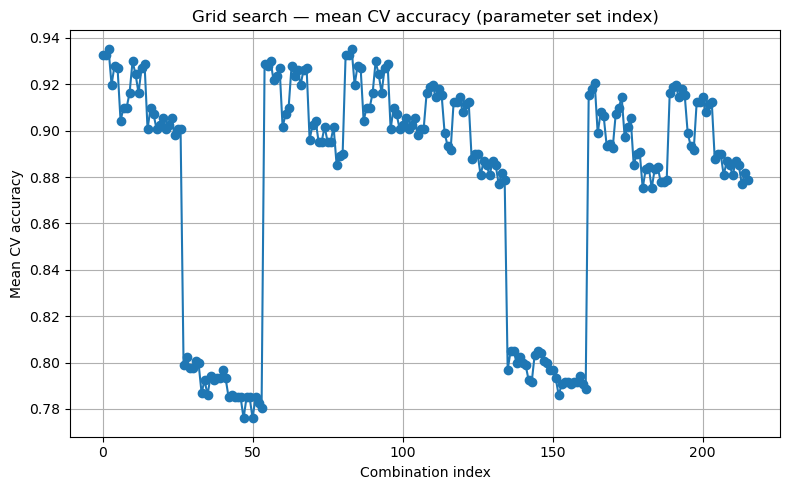

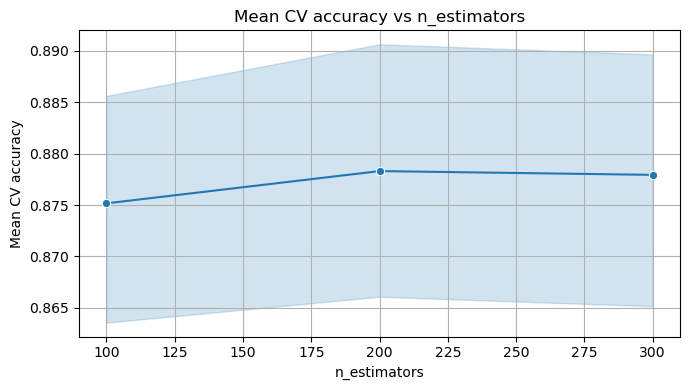

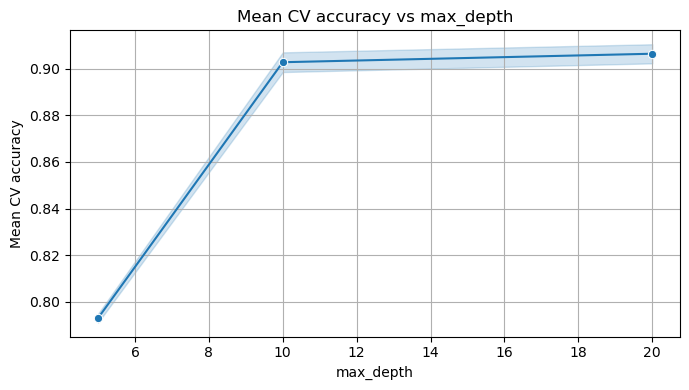

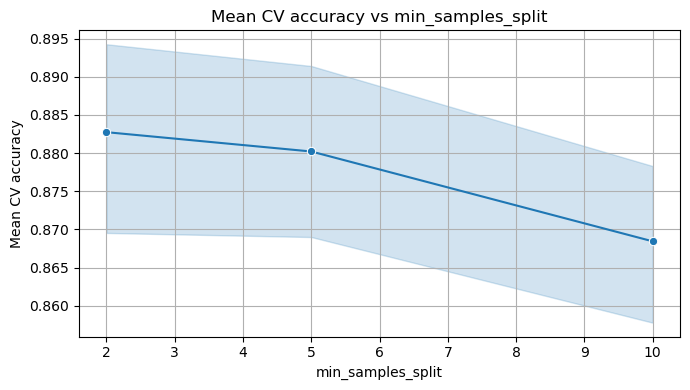

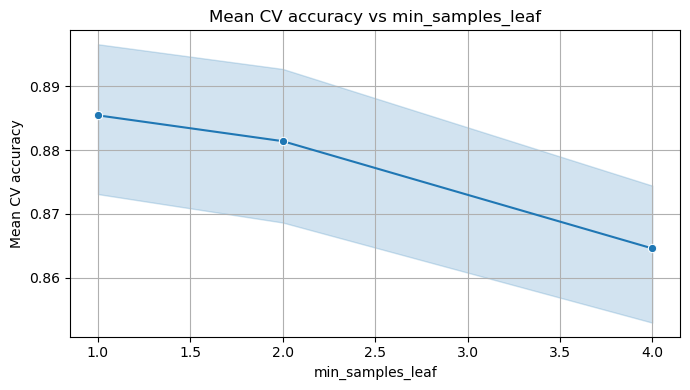

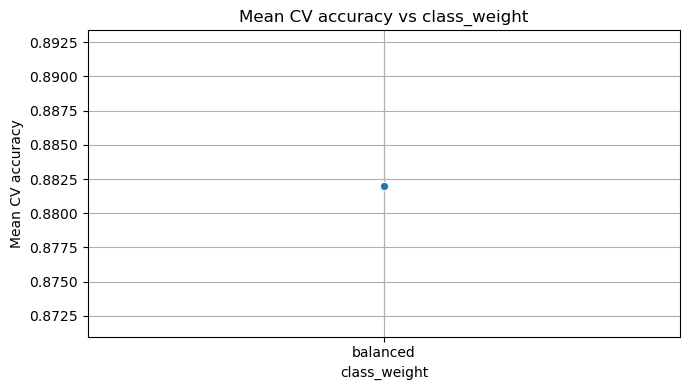

In [14]:
param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 5, 10, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "class_weight": ["balanced", None],
}

rf_grid = RandomForestClassifier(random_state=42)
grid_search = GridSearchCV(
    rf_grid, param_grid, cv=3, scoring="accuracy", n_jobs=-1, verbose=1
)
grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best CV accuracy: {:.3f}".format(grid_search.best_score_))

results = grid_search.cv_results_
plt.figure(figsize=(8, 5))
plt.plot(results["mean_test_score"], marker="o")
plt.title("Grid search — mean CV accuracy (parameter set index)")
plt.xlabel("Combination index")
plt.ylabel("Mean CV accuracy")
plt.grid(True)
plt.tight_layout()
plt.show()

import seaborn as sns

def plot_param_search(results, param_name):
    key = f"param_{param_name}"
    if key not in results:
        print(f"Missing {key}")
        return
    plt.figure(figsize=(7, 4))
    sns.lineplot(x=list(results[key]), y=results["mean_test_score"], marker="o")
    plt.title(f"Mean CV accuracy vs {param_name}")
    plt.xlabel(param_name)
    plt.ylabel("Mean CV accuracy")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

for p in ["n_estimators", "max_depth", "min_samples_split", "min_samples_leaf", "class_weight"]:
    plot_param_search(results, p)


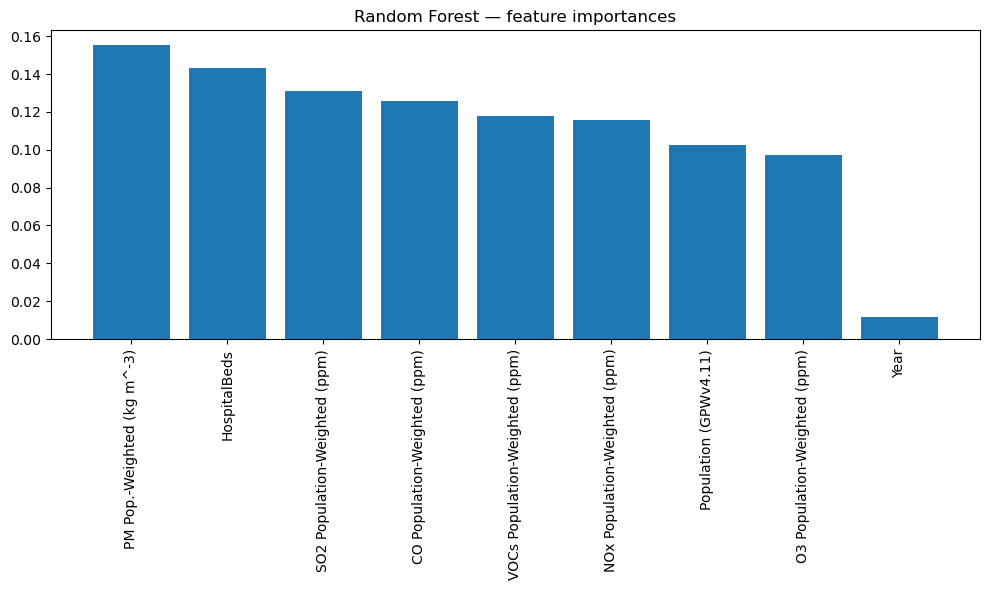

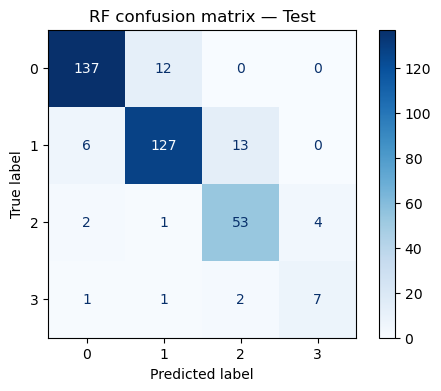


Test — classification report
              precision    recall  f1-score   support

           0       0.94      0.92      0.93       149
           1       0.90      0.87      0.89       146
           2       0.78      0.88      0.83        60
           3       0.64      0.64      0.64        11

    accuracy                           0.89       366
   macro avg       0.81      0.83      0.82       366
weighted avg       0.89      0.89      0.89       366



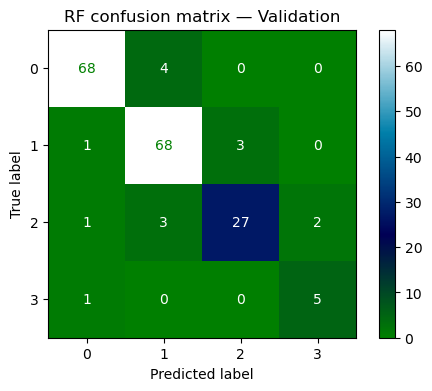


Validation — classification report
              precision    recall  f1-score   support

           0       0.96      0.94      0.95        72
           1       0.91      0.94      0.93        72
           2       0.90      0.82      0.86        33
           3       0.71      0.83      0.77         6

    accuracy                           0.92       183
   macro avg       0.87      0.89      0.88       183
weighted avg       0.92      0.92      0.92       183



In [15]:
# Final Random Forest (explicit config; can replace with grid_search.best_estimator_)

# According to grid search, best params are:
# class_weight='balanced', max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=300
# with mean CV accuracy ≈ 0.935

# (already set below, but now explicitly comment)
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=1,
    min_samples_split=2,
    class_weight="balanced",
    random_state=42,
)



rf.fit(X_train, y_train)

val_preds = rf.predict(X_val)
test_preds = rf.predict(X_test)

importances = rf.feature_importances_
order = importances.argsort()[::-1]
plt.figure(figsize=(10, 6))
plt.bar(range(len(FEATURE_COLS)), importances[order])
plt.xticks(range(len(FEATURE_COLS)), [FEATURE_COLS[i] for i in order], rotation=90)
plt.title("Random Forest — feature importances")
plt.tight_layout()
plt.show()

for name, y_true, y_pred in [
    ("Test", y_test, test_preds),
    ("Validation", y_val, val_preds),
]:
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=sorted(y_true.unique()))
    fig, ax = plt.subplots(figsize=(6, 4))
    disp.plot(ax=ax, cmap="Blues" if name == "Test" else "ocean", values_format="d")
    plt.title(f"RF confusion matrix — {name}")
    plt.show()
    print(f"\n{name} — classification report")
    print(classification_report(y_true, y_pred))


In [16]:
train_acc = accuracy_score(y_train, rf.predict(X_train))
val_acc = accuracy_score(y_val, val_preds)
test_acc = accuracy_score(y_test, test_preds)
print(f"RF train accuracy: {train_acc:.3f}")
print(f"RF validation accuracy: {val_acc:.3f}")
print(f"RF test accuracy: {test_acc:.3f}")
if train_acc - val_acc > 0.1:
    print("Note: possible overfitting (train much higher than val).")
elif val_acc > train_acc:
    print("Note: unusual pattern val > train — check data shift or small val size.")
else:
    print("Train/val gap looks moderate.")


RF train accuracy: 1.000
RF validation accuracy: 0.918
RF test accuracy: 0.885
Train/val gap looks moderate.


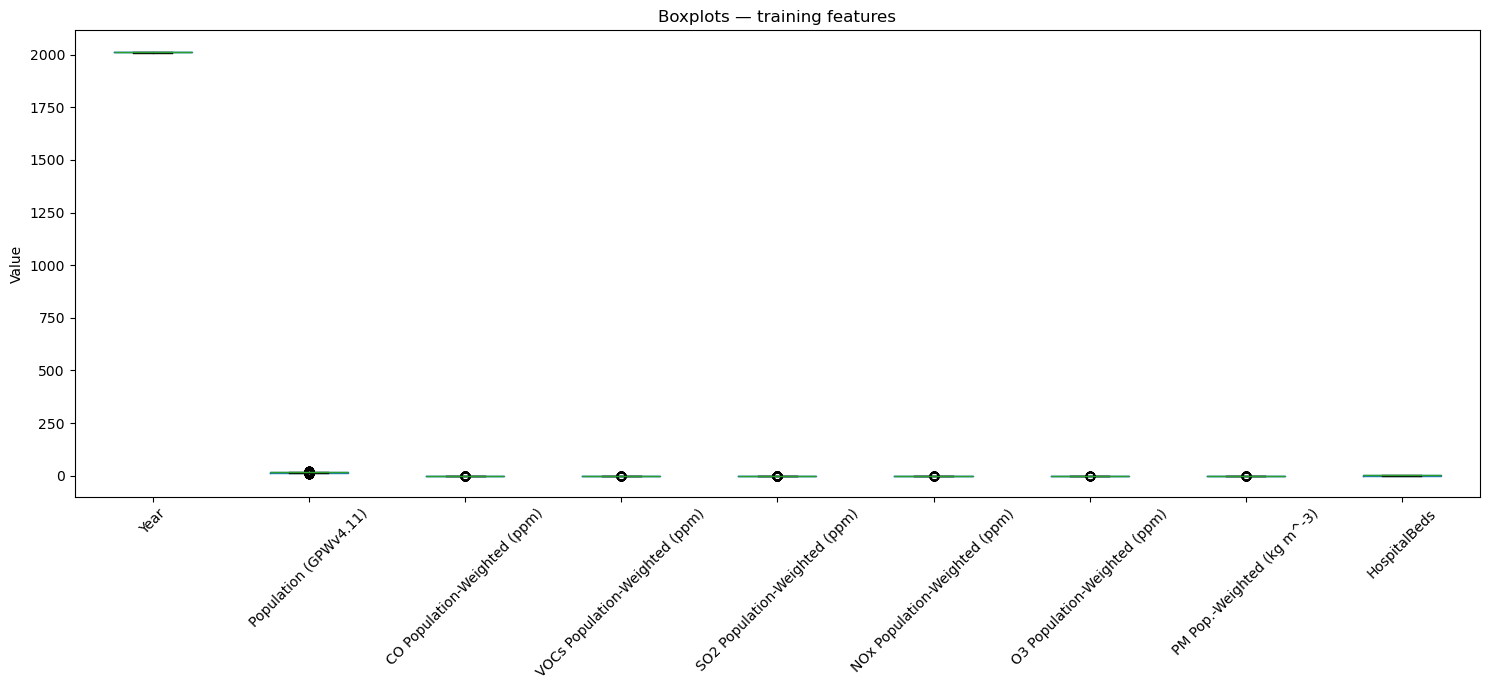

In [17]:
# Training feature distributions — spot outliers / scale differences
num_features = X_train.select_dtypes(include="number").columns
plt.figure(figsize=(15, 7))
X_train[num_features].boxplot(rot=45, grid=False)
plt.title("Boxplots — training features")
plt.ylabel("Value")
plt.tight_layout()
plt.show()


## 12. KNN classifier

`GridSearchCV` over `n_neighbors` ∈ [1, 20] with **cv=5**. The following cell fits **KNN with n_neighbors=1** as in the original notebook (high capacity, risk of overfitting); consider **`best_knn = grid_search.best_estimator_`** for production use.


Best KNN n_neighbors: {'n_neighbors': 1}
Best cross-val accuracy: 0.5001203819012038


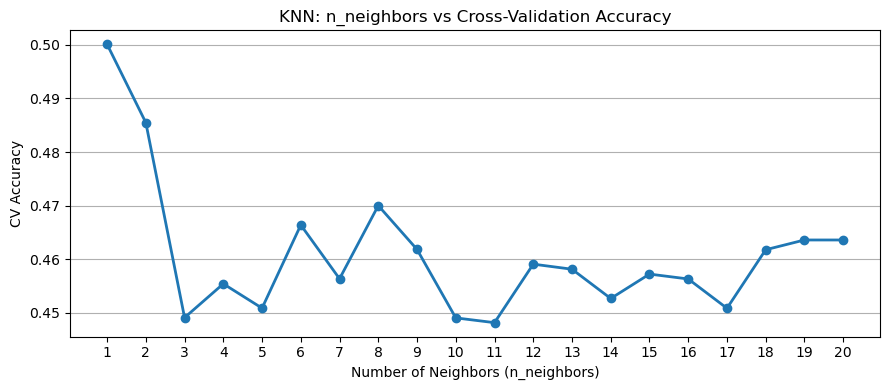

In [18]:
from sklearn.model_selection import GridSearchCV

knn_grid = {'n_neighbors': list(range(1, 21))}
knn_model = KNeighborsClassifier()

grid_search = GridSearchCV(knn_model, knn_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train, y_train)

print("Best KNN n_neighbors:", grid_search.best_params_)
print("Best cross-val accuracy:", grid_search.best_score_)
best_knn = grid_search.best_estimator_

# Plot n_neighbors vs cross-validation accuracy ("gigram" = line/marker plot)
mean_test_scores = grid_search.cv_results_["mean_test_score"]
n_neighbors_range = knn_grid['n_neighbors']
plt.figure(figsize=(9, 4))
plt.plot(n_neighbors_range, mean_test_scores, marker='o', lw=2)
plt.xticks(n_neighbors_range)
plt.xlabel("Number of Neighbors (n_neighbors)")
plt.ylabel("CV Accuracy")
plt.title("KNN: n_neighbors vs Cross-Validation Accuracy")
plt.grid(True, axis='y')
plt.tight_layout()
plt.show()




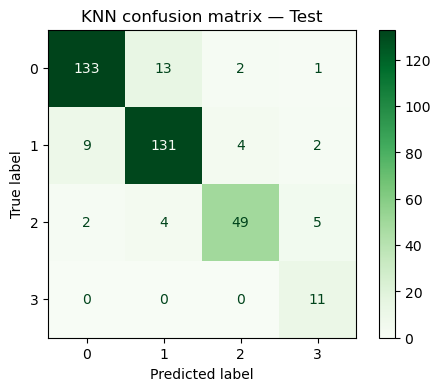


Test — KNN report
              precision    recall  f1-score   support

           0       0.92      0.89      0.91       149
           1       0.89      0.90      0.89       146
           2       0.89      0.82      0.85        60
           3       0.58      1.00      0.73        11

    accuracy                           0.89       366
   macro avg       0.82      0.90      0.85       366
weighted avg       0.89      0.89      0.89       366



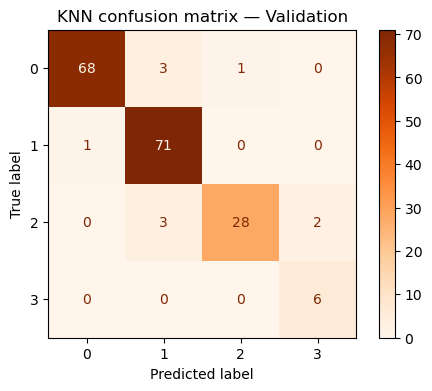


Validation — KNN report
              precision    recall  f1-score   support

           0       0.99      0.94      0.96        72
           1       0.92      0.99      0.95        72
           2       0.97      0.85      0.90        33
           3       0.75      1.00      0.86         6

    accuracy                           0.95       183
   macro avg       0.91      0.94      0.92       183
weighted avg       0.95      0.95      0.95       183



In [19]:
# Use n_neighbors=1 to match original notebook; swap to best_knn for tuned model
knn = KNeighborsClassifier(n_neighbors=1)
knn.fit(X_train, y_train)

knn_val_preds = knn.predict(X_val)
knn_test_preds = knn.predict(X_test)

for name, y_true, y_pred in [
    ("Test", y_test, knn_test_preds),
    ("Validation", y_val, knn_val_preds),
]:
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=sorted(y_true.unique()))
    fig, ax = plt.subplots(figsize=(6, 4))
    disp.plot(ax=ax, cmap="Greens" if name == "Test" else "Oranges", values_format="d")
    plt.title(f"KNN confusion matrix — {name}")
    plt.show()
    print(f"\n{name} — KNN report")
    print(classification_report(y_true, y_pred))


In [20]:
print(f"KNN train: {knn.score(X_train, y_train):.3f}")
print(f"KNN val:   {knn.score(X_val, y_val):.3f}")
print(f"KNN test:  {knn.score(X_test, y_test):.3f}")


KNN train: 1.000
KNN val:   0.945
KNN test:  0.885


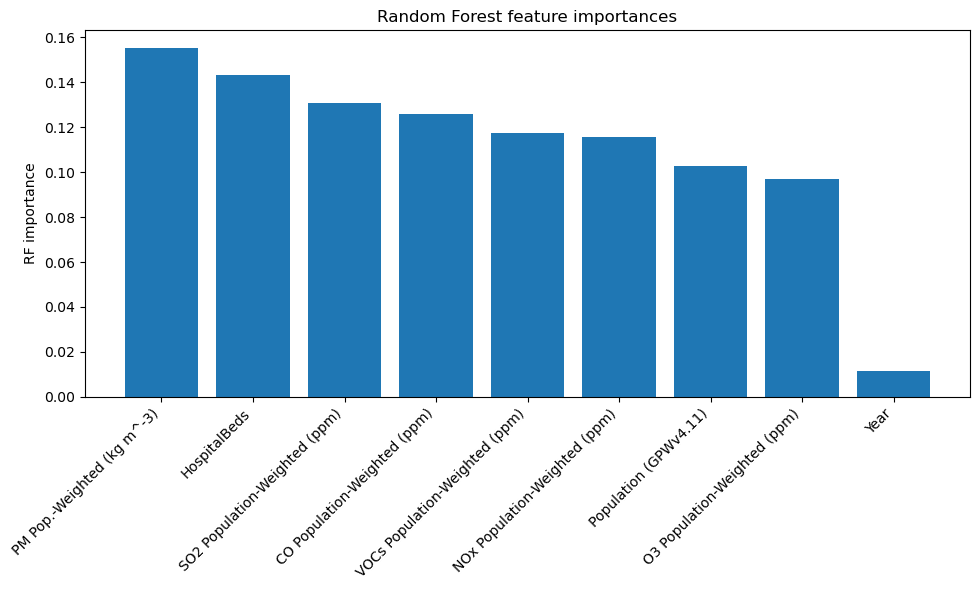

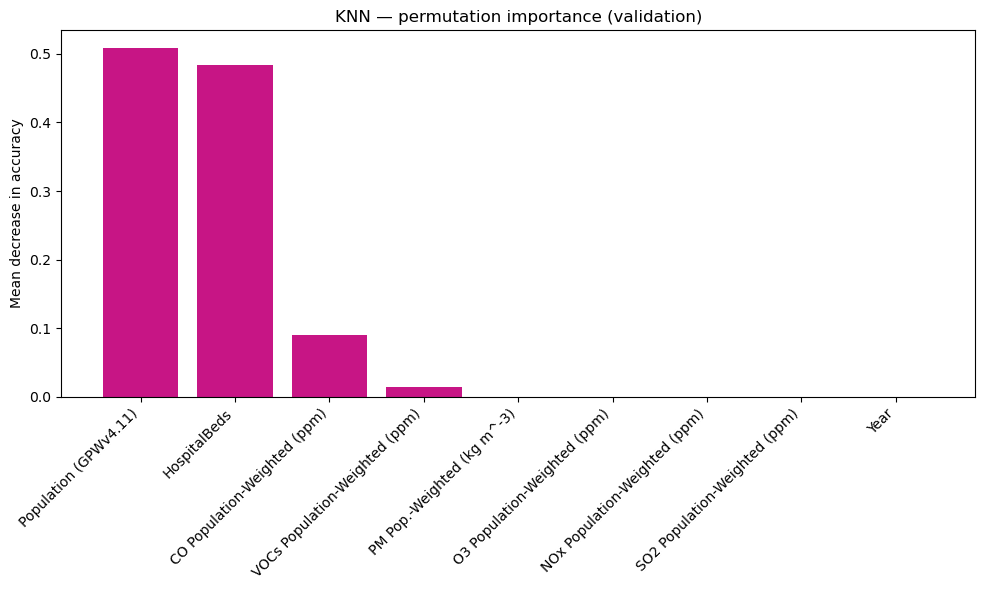

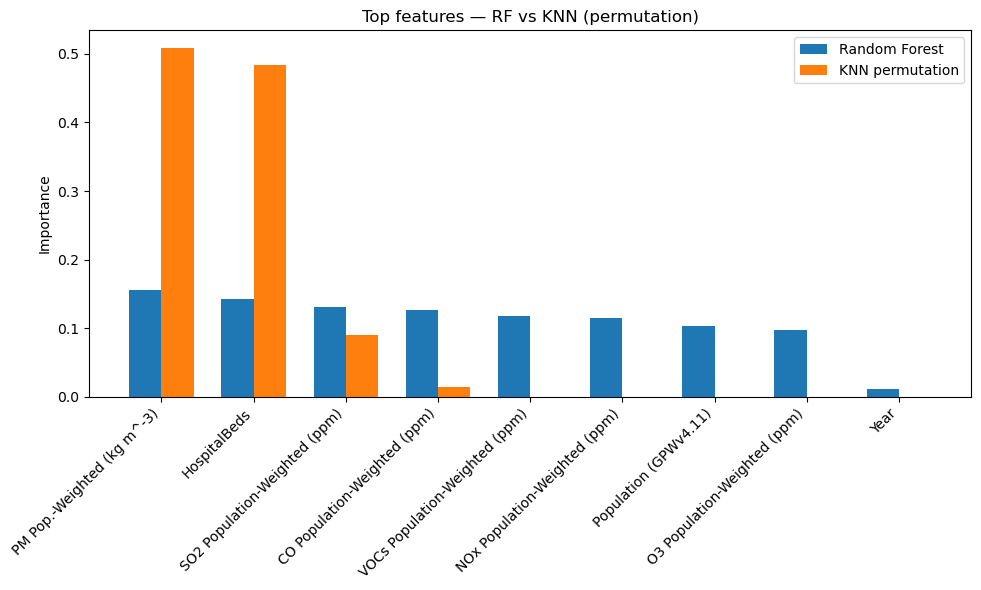

In [21]:
# RF importances vs KNN permutation importance (validation set)
feat_names = list(X_train.columns)
fi = rf.feature_importances_
idx_rf = fi.argsort()[::-1]

r_knn = permutation_importance(knn, X_val, y_val, n_repeats=10, random_state=42, scoring="accuracy")
pi = r_knn.importances_mean
idx_pi = pi.argsort()[::-1]

top_n = len(feat_names)
plt.figure(figsize=(10, 6))
plt.bar(range(top_n), fi[idx_rf])
plt.xticks(range(top_n), np.array(feat_names)[idx_rf], rotation=45, ha="right")
plt.ylabel("RF importance")
plt.title("Random Forest feature importances")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
plt.bar(range(top_n), pi[idx_pi], color="mediumvioletred")
plt.xticks(range(top_n), np.array(feat_names)[idx_pi], rotation=45, ha="right")
plt.ylabel("Mean decrease in accuracy")
plt.title("KNN — permutation importance (validation)")
plt.tight_layout()
plt.show()

n_compare = min(10, top_n)
x = np.arange(n_compare)
w = 0.35
plt.figure(figsize=(10, 6))
plt.bar(x - w / 2, fi[idx_rf][:n_compare], w, label="Random Forest")
plt.bar(x + w / 2, pi[idx_pi][:n_compare], w, label="KNN permutation")
plt.xticks(x, np.array(feat_names)[idx_rf][:n_compare], rotation=45, ha="right")
plt.ylabel("Importance")
plt.title("Top features — RF vs KNN (permutation)")
plt.legend()
plt.tight_layout()
plt.show()


Model Score Summary:
----------------------------------------
Random Forest (train): 1.000
Random Forest (val):   0.918
Random Forest (test):  0.885
KNN (train):           1.000
KNN (val):             0.945
KNN (test):            0.885

Best model on validation set: KNN
Validation score: 0.945
Test score:       0.885


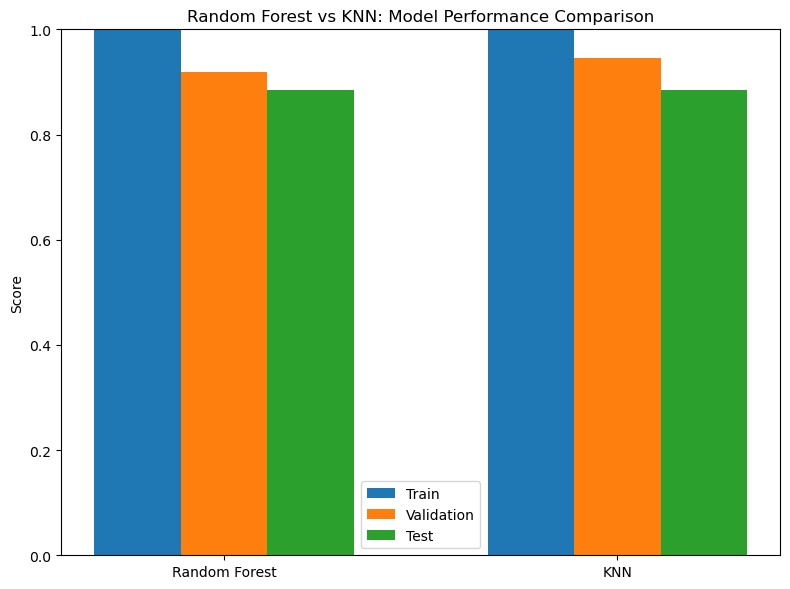

In [22]:
# Analyze and compare the performance of both models: Random Forest and KNN

print("Model Score Summary:")
print("-" * 40)
print(f"Random Forest (train): {rf.score(X_train, y_train):.3f}")
print(f"Random Forest (val):   {rf.score(X_val, y_val):.3f}")
print(f"Random Forest (test):  {rf.score(X_test, y_test):.3f}")
print(f"KNN (train):           {knn.score(X_train, y_train):.3f}")
print(f"KNN (val):             {knn.score(X_val, y_val):.3f}")
print(f"KNN (test):            {knn.score(X_test, y_test):.3f}")

# Pick best model based on validation or test set
rf_val_score = rf.score(X_val, y_val)
knn_val_score = knn.score(X_val, y_val)
rf_test_score = rf.score(X_test, y_test)
knn_test_score = knn.score(X_test, y_test)

if rf_val_score > knn_val_score:
    best_model_name = "Random Forest"
    best_score = rf_val_score
    best_test_score = rf_test_score
else:
    best_model_name = "KNN"
    best_score = knn_val_score
    best_test_score = knn_test_score

print("\nBest model on validation set:", best_model_name)
print(f"Validation score: {best_score:.3f}")
print(f"Test score:       {best_test_score:.3f}")
import matplotlib.pyplot as plt

# Bar plot to visually compare performance of Random Forest and KNN on train, validation, and test splits
model_names = ['Random Forest', 'KNN']
scores_train = [rf.score(X_train, y_train), knn.score(X_train, y_train)]
scores_val = [rf.score(X_val, y_val), knn.score(X_val, y_val)]
scores_test = [rf.score(X_test, y_test), knn.score(X_test, y_test)]

x = np.arange(len(model_names))
width = 0.22

plt.figure(figsize=(8, 6))
plt.bar(x - width, scores_train, width, label='Train')
plt.bar(x,        scores_val,   width, label='Validation')
plt.bar(x + width, scores_test, width, label='Test')
plt.xticks(x, model_names)
plt.ylabel('Score')
plt.ylim(0, 1)
plt.title('Random Forest vs KNN: Model Performance Comparison')
plt.legend()
plt.tight_layout()
plt.show()



| Criteria                         | Random Forest                          | KNN                                      |
|-----------------------------------|----------------------------------------|-------------------------------------------|
| Uses all features effectively     | Yes                                    | No (only a few matter)                    |
| Built-in feature importance       | Yes                                    | No (needs permutation importance)         |
| Handles class imbalance           | Yes (class weighting)                  | No built-in mechanism                     |
| Risk of overfitting               | Low (ensemble of trees)                | High (especially with k=1)                |
| Needs feature scaling             | No                                     | Yes                                       |
| Interpretability                  | Feature importances available          | Limited                                   |

## 13. Closing notes

1. **Target** = ordered **mortality_cluster** from **DeathRate-only** KMeans; multi-feature KMeans was rejected for target definition due to overlapping DeathRate ranges.
2. **Leakage control:** **DeathRate** dropped before supervised learning.
3. **Evaluation:** time split reduces optimistic bias vs random split for panel data.
4. **Next steps:** use `grid_search.best_estimator_` for RF; use `best_knn` (or best `n_neighbors`) for KNN; try stratified splits within year if classes are imbalanced; consider class-weighted or macro-F1 metrics if accuracy is misleading.

---
*Notebook generated as a structured companion to `Air_Pollution_Death_Rate_Analysis_categorical.ipynb`.*
